# Treadmill Buyer Profile
Tenemos 1 dataset con 3 tipos de cintas de correr y datos relacionados con sus compradores. Hay que ver si hay los compradores de un tipo de cinta comparten caracteristicas para mejorar las recomendaciones a futuros clientes. 

Para cada cinta hay que crear tablas de contingencia y calcular las probabilidades marginales y condicionales.

- La KP281 es una cinta de correr de nivel de entrada por 1500 $
- La KP481 es una cinta de correr de nivel medio por 1700 $
- La KP781 es una cinta de correr de nivel experto con varios extras que se vende por 2500 $

In [1]:
import pandas as pd
aerofit_df = pd.read_csv('datasets/aerofit_treadmill_data.csv')
aerofit_df.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


Algunas aclaraciones que nos da la pagina sobre algunas columnas son:
- Education: en años
- Usage: días que planean utilizarla por semana
- Fitness: Autoevaluacion fisica del 1-5, donde 1 es baja forma fisica y 5 excelente.
- Income: dolares por año
- Miles: millas que esperan caminar/andar por semana.

## Data Exploration

In [2]:
aerofit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


El dataset no tiene valores nulos, hay 6 variables numericas y 3 categoricas.

In [3]:
aerofit_df.describe()

,Age,Education,Usage,Fitness,Income,Miles
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,28.788889,15.572222,3.455556,3.311111,53719.577778,103.194444
std,6.943498,1.617055,1.084797,0.958869,16506.684226,51.863605
min,18.000000,12.000000,2.000000,1.000000,29562.000000,21.000000
25%,24.000000,14.000000,3.000000,3.000000,44058.750000,66.000000
50%,26.000000,16.000000,3.000000,3.000000,50596.500000,94.000000
75%,33.000000,16.000000,4.000000,4.000000,58668.000000,114.750000
max,50.000000,21.000000,7.000000,5.000000,104581.000000,360.000000


In [4]:
categoricas = ['Product', 'Gender', 'MaritalStatus']

for variable in categoricas:
    print(f"\n=== {variable} ===")
    print("Número de categorías")
    print(aerofit_df[variable].nunique())

    print("Frecuencia absoluta:")
    print(aerofit_df[variable].value_counts())

    print("\nFrecuencia relativa (%):")
    print(aerofit_df[variable].value_counts(normalize=True) * 100)


=== Product ===
Número de categorías
3
Frecuencia absoluta:
Product
KP281    80
KP481    60
KP781    40
Name: count, dtype: int64

Frecuencia relativa (%):
Product
KP281    44.444444
KP481    33.333333
KP781    22.222222
Name: proportion, dtype: float64

=== Gender ===
Número de categorías
2
Frecuencia absoluta:
Gender
Male      104
Female     76
Name: count, dtype: int64

Frecuencia relativa (%):
Gender
Male      57.777778
Female    42.222222
Name: proportion, dtype: float64

=== MaritalStatus ===
Número de categorías
2
Frecuencia absoluta:
MaritalStatus
Partnered    107
Single        73
Name: count, dtype: int64

Frecuencia relativa (%):
MaritalStatus
Partnered    59.444444
Single       40.555556
Name: proportion, dtype: float64


Con .describe() se hace un analisis rapido de las variables numericas y despues utilizamos la funcion para analizar las variables categoricas. Las observaciones más relevantes son:
 - No hay valores faltantes en el dataset.
 - Hay 3 productos de los cuales el modelo KP281 de entrada es el más frecuente. 
 - Edad minima 18, maxima 50 pero el 75% de las personas tienen menos o igual a 33.
 - Casi el 60% de los compradores son hombres y casi el 60% de las personas tiene pareja.
 - El 75% de la gente tiene menos de 16 años de educacion.
 - La desviacion en Income y Miles es muy grande por lo que podremos encontrar outliers.



## Análisis gráfico

### Análisis univariable

Empezamos generando histogramas junto a Estimaciones de Densidad Kernel. El histograma agrupa las variables numéricas en bins y KDE estima la densidad suavizada.

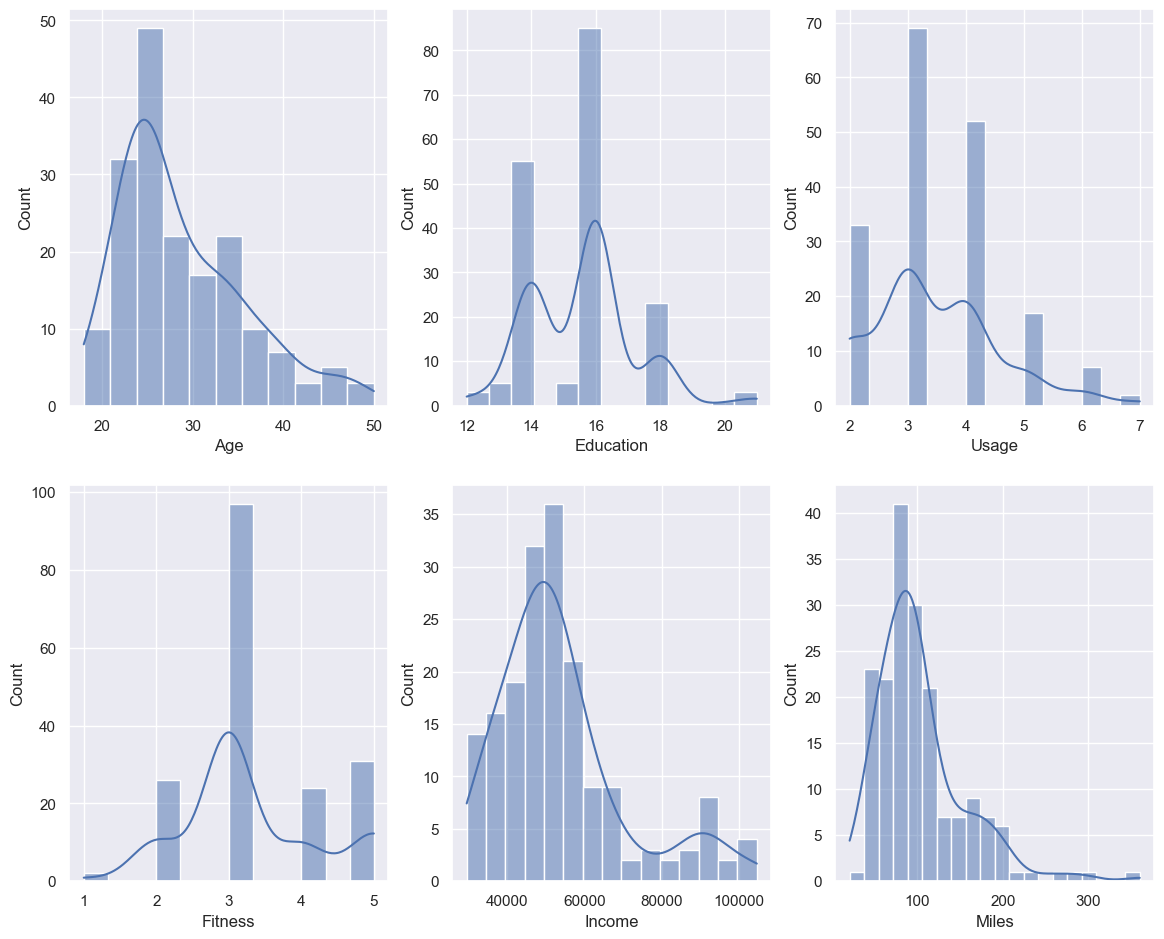

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(color_codes = True)

#HISTOGRAMAS
hist_fig, hist_axes = plt.subplots(2, 3, figsize=(14,8))
hist_fig.subplots_adjust(top =1.2)

sns.histplot(aerofit_df['Age'], kde=True, ax=hist_axes[0,0])
sns.histplot(aerofit_df['Education'], kde=True, ax=hist_axes[0,1])
sns.histplot(aerofit_df['Usage'], kde=True, ax=hist_axes[0,2])
sns.histplot(aerofit_df['Fitness'], kde=True, ax=hist_axes[1,0])
sns.histplot(aerofit_df['Income'], kde=True, ax=hist_axes[1,1])
sns.histplot(aerofit_df['Miles'], kde=True, ax=hist_axes[1,2])
plt.show()

Aqui simplemente vemos lo que hemos comentado en el análisis exploratorio.
- La gente joven, con sueldos entre 45-60 k $ son las que más compran y mejor se pueden dirigir los productos.

Box Plot: Representa una serie de valores clave en el rango de los datos. 
 - La caja esta compuesta por el IQR (InterQuantile Range = Q3-Q1) que son todos los datos entre el Q1 (<=25%) y Q3 (<=75%). Además, una linea en el medio representa la mediana de los datos (Q2=50%)
 - Dos bigotes. Es el valor más lejano dentro 1.5 x IQR. Los valores que se encuentren por fuera de estos bigotes, se consideran outliers y se marcan con un punto.

Ej: en el caso de ['Age']: 25%=24 y 75%=33. 50% = 26. IQR=Q3-Q1=9 . Bigotes=1.5 x IQR = 13.5 
=>Q1-Bigote=10.5 y Q3+Bigote=46.5

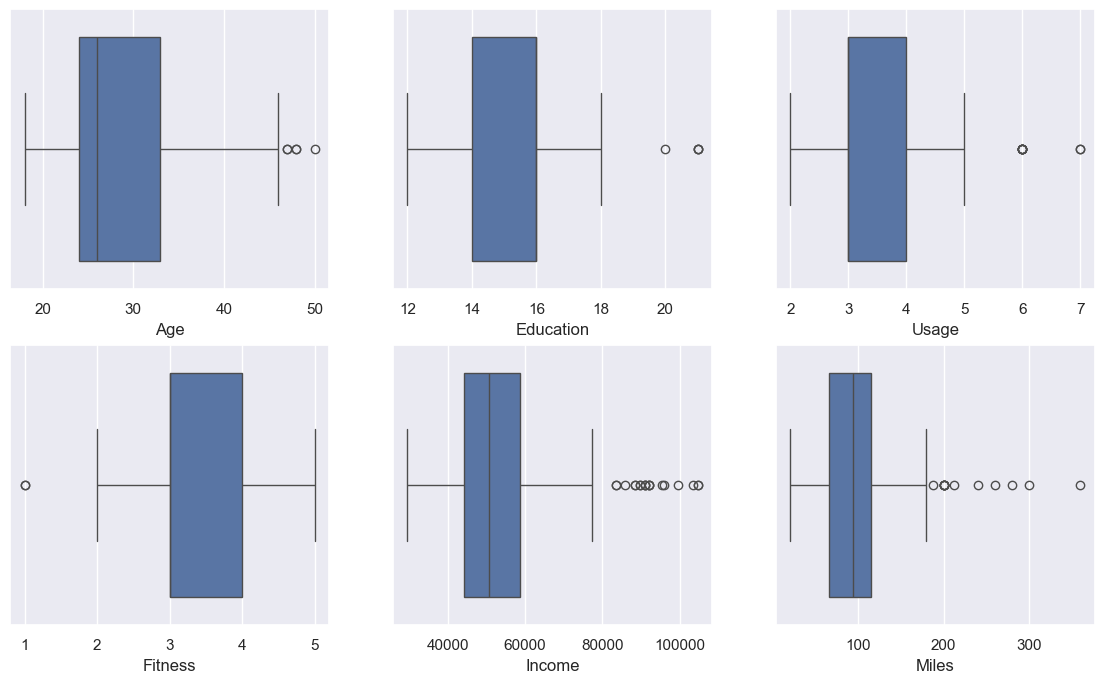

In [6]:
#BOXPLOT
box_fig, box_axes = plt.subplots(2, 3, figsize=(14,8))
hist_fig.subplots_adjust(top =1.2)

sns.boxplot(data=aerofit_df, x="Age", ax=box_axes[0,0])
sns.boxplot(data=aerofit_df, x="Education", ax=box_axes[0,1])
sns.boxplot(data=aerofit_df, x="Usage", ax=box_axes[0,2])
sns.boxplot(data=aerofit_df, x="Fitness", ax=box_axes[1,0])
sns.boxplot(data=aerofit_df, x="Income", ax=box_axes[1,1])
sns.boxplot(data=aerofit_df, x="Miles", ax=box_axes[1,2])
plt.show()

Aqui se puede ver como claramente Income tiene muchos outliers, seguido de Miles. Age, Education, Usage y Fitness apenas tienen.

Ahora le toca el turno a las variables categóricas.

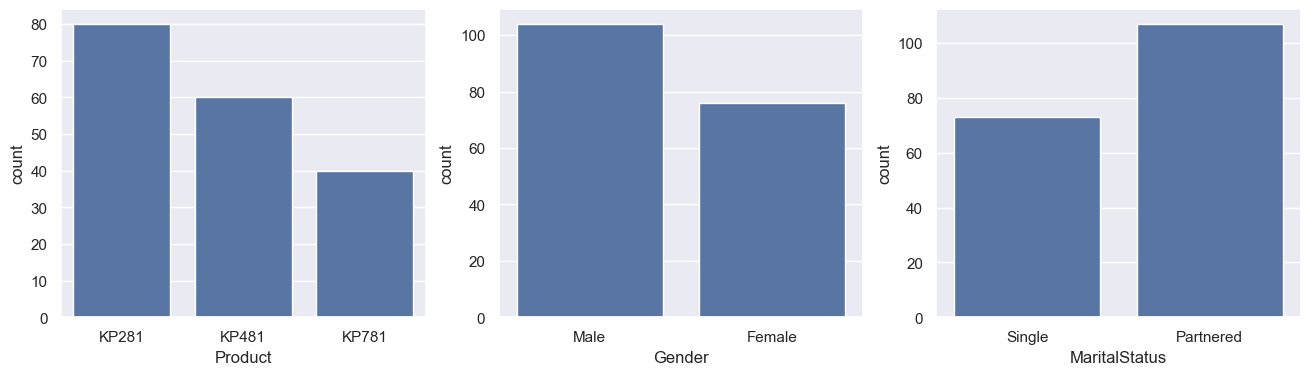

In [7]:
#COUNT PLOT
categorical_fig, categorical_axes = plt.subplots (1, 3, figsize=(16,4))

sns.countplot(data=aerofit_df, x='Product', ax=categorical_axes[0])
sns.countplot(data=aerofit_df, x='Gender', ax=categorical_axes[1])
sns.countplot(data=aerofit_df, x='MaritalStatus', ax=categorical_axes[2])
plt.show()

### Análisis de dos variables

El primer paso, aunque Strata Scratch no lo hace es preagregar los datos para ver que porcentaje de una variable ha comprado más un producto. Si no hacemos este paso podemos obtener datos como que los hombres compran más el KP281, que sería correcto pero en parte es porque los hombres hacen en general más compras, como hemos visto justo en el gráfico anterior.

In [ ]:
# Cruzamos los datos de productos con las variables Gender y MaritalStatus
prod_gender = (
    pd.crosstab(
        aerofit_df['Product'],
        aerofit_df['Gender'],
        normalize='index'
    ) *100
).reset_index()

prod_marsta = (
    pd.crosstab(
        aerofit_df['Product'],
        aerofit_df['MaritalStatus'],
        normalize='index'
    ) *100
).reset_index()

In [9]:
# Hacemos melt para pasar a un formato largo más adaptado para sns
prod_gender_long = prod_gender.melt(
    id_vars='Product',
    var_name='Gender',
    value_name='Percentage'
)

prod_marsta_long = prod_marsta.melt(
    id_vars='Product',
    var_name='MaritalStatus',
    value_name='Percentage'
)


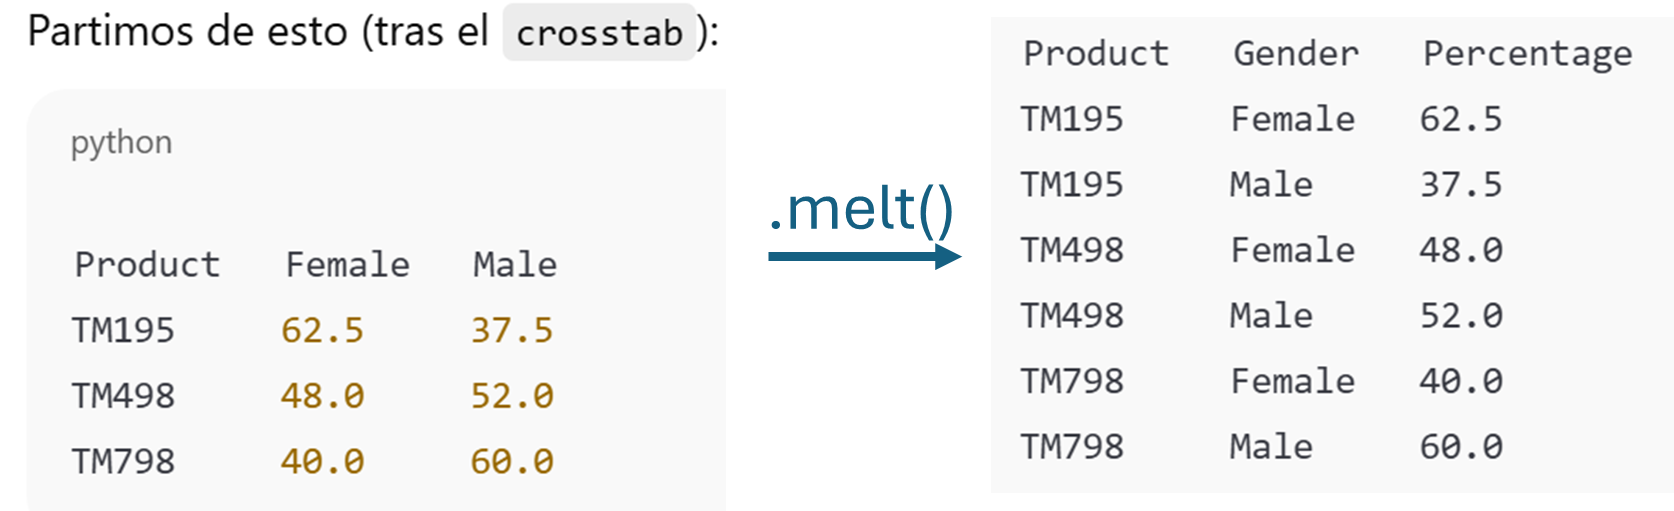

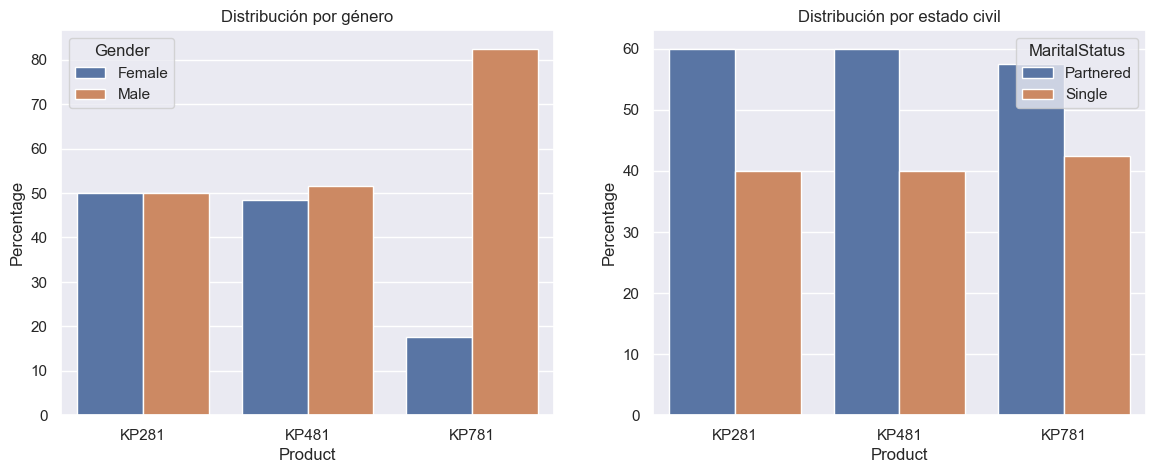

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.barplot(data=prod_gender_long,x='Product', y='Percentage',hue='Gender', ax=axes[0])
axes[0].set_title('Distribución por género')

sns.barplot(data=prod_marsta_long,x='Product',y='Percentage',hue='MaritalStatus',ax=axes[1])
axes[1].set_title('Distribución por estado civil')

plt.show()

La diferencia de género es inapreciable en los productos KP281 y KP481 sin embargo en el de alta gama predomina 4 veces más las compras de hombres.

Las personas que se encuentran en una pareja también son más propensas a comprar cualquiera de las cintas de correr.

En el caso de la comparación Edad-Producto optamos por agrupar las fechas en varios rangos de edad para que la visualización sea un poco más fácil de ver.

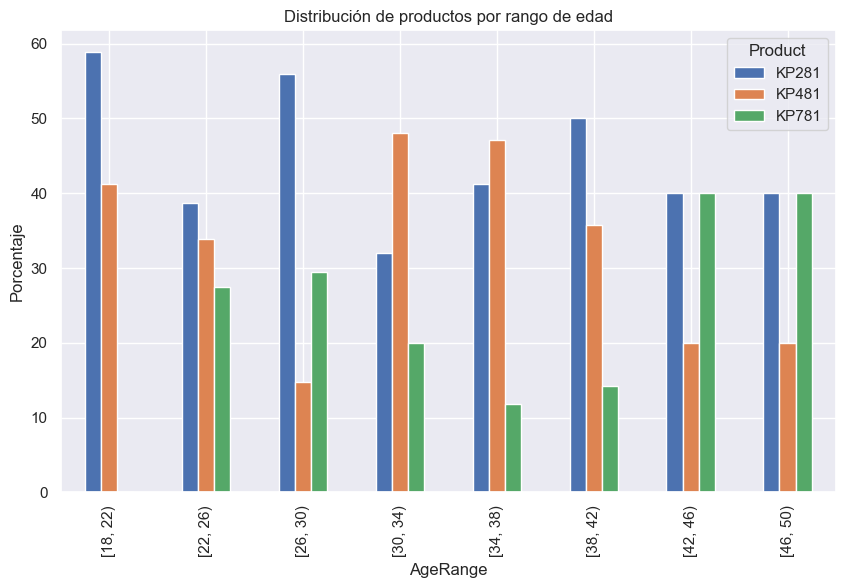

In [ ]:
# Agrupamos fechas en bins de 4 años empezando en los 18 (min) hasta 54 (max). Cut lo agrupa y después 
# los datos se tratan como en los ejemplos anteriores.
import numpy as np

bins = np.arange(18, 54, 4)
aerofit_df['AgeRange'] = pd.cut(
    aerofit_df['Age'],
    bins=bins,
    right=False
)
age_product_pct = pd.crosstab(
    aerofit_df['AgeRange'],
    aerofit_df['Product'],
    normalize='index'
) * 100
age_product_pct.plot(
    kind='bar',
    #stacked=True, otro posible grafico que podemos hacer
    figsize=(10,6)
)

plt.ylabel('Porcentaje')
plt.title('Distribución de productos por rango de edad')
plt.legend(title='Product')
plt.show()


Observaciones destacadas:
- Entre 18-22 años no hay un solo registro de compra de KP781. Los modelos más caros son inaccesibles para los más jovenes.
- Entre los 30-38 años, la franja media de edad de los compradores destaca la compra de la KP481, de gama media.
- La gente de 42-50 años, con mayores ingresos y ahorros, elevvan la compra de los modelos KP781.

Vamos a ver ahora las variables numéricas. Vamos a representarlas con un loop

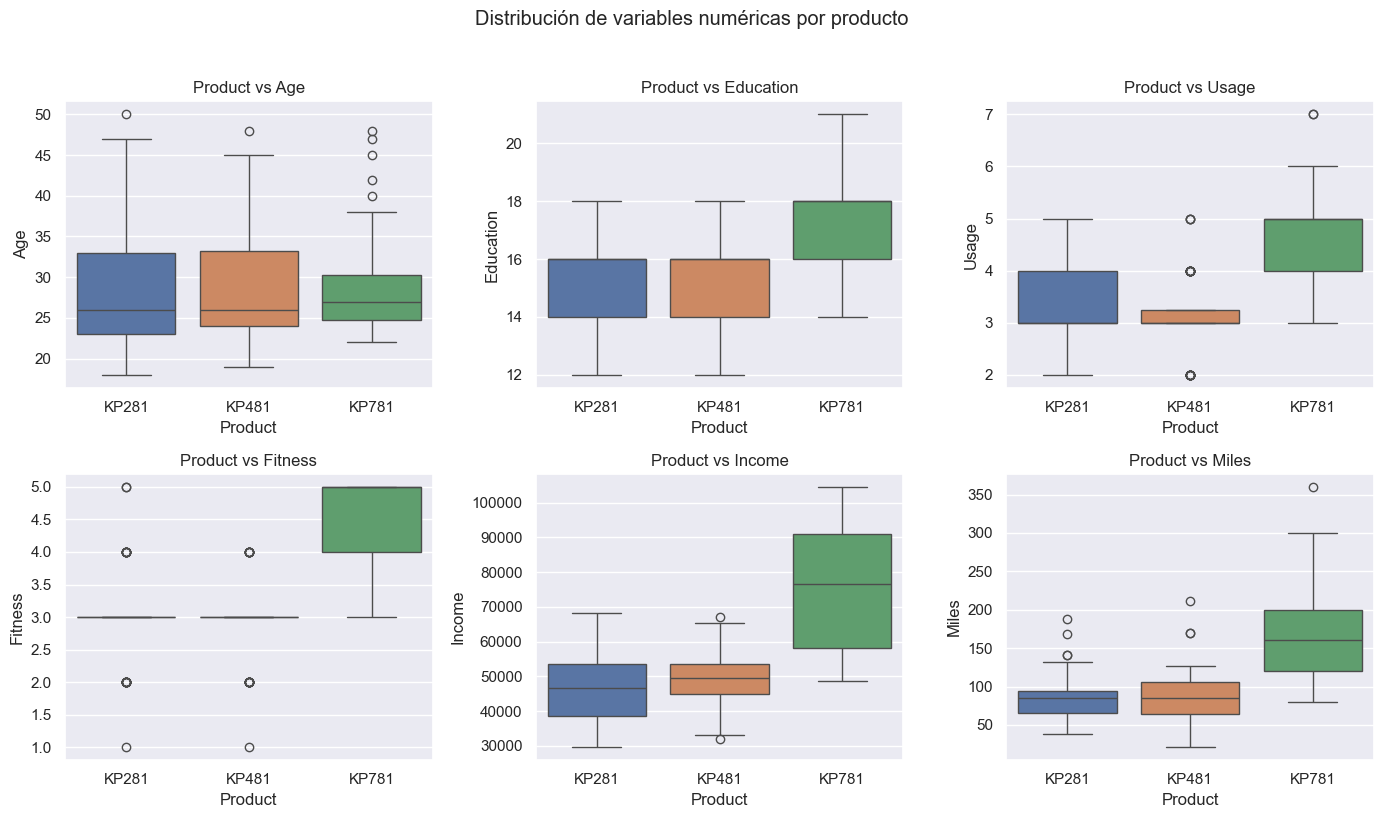

In [25]:
attributes = ['Age', 'Education', 'Usage', 'Fitness', 'Income', 'Miles']


fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Distribución de variables numéricas por producto", y=1.02)

for ax, attr in zip(axes.flatten(), attributes):
    sns.boxplot(
        data=aerofit_df,
        x='Product',
        hue='Product',
        y=attr,
        ax=ax
    )
    ax.set_title(f"Product vs {attr}")

plt.tight_layout()
plt.show()


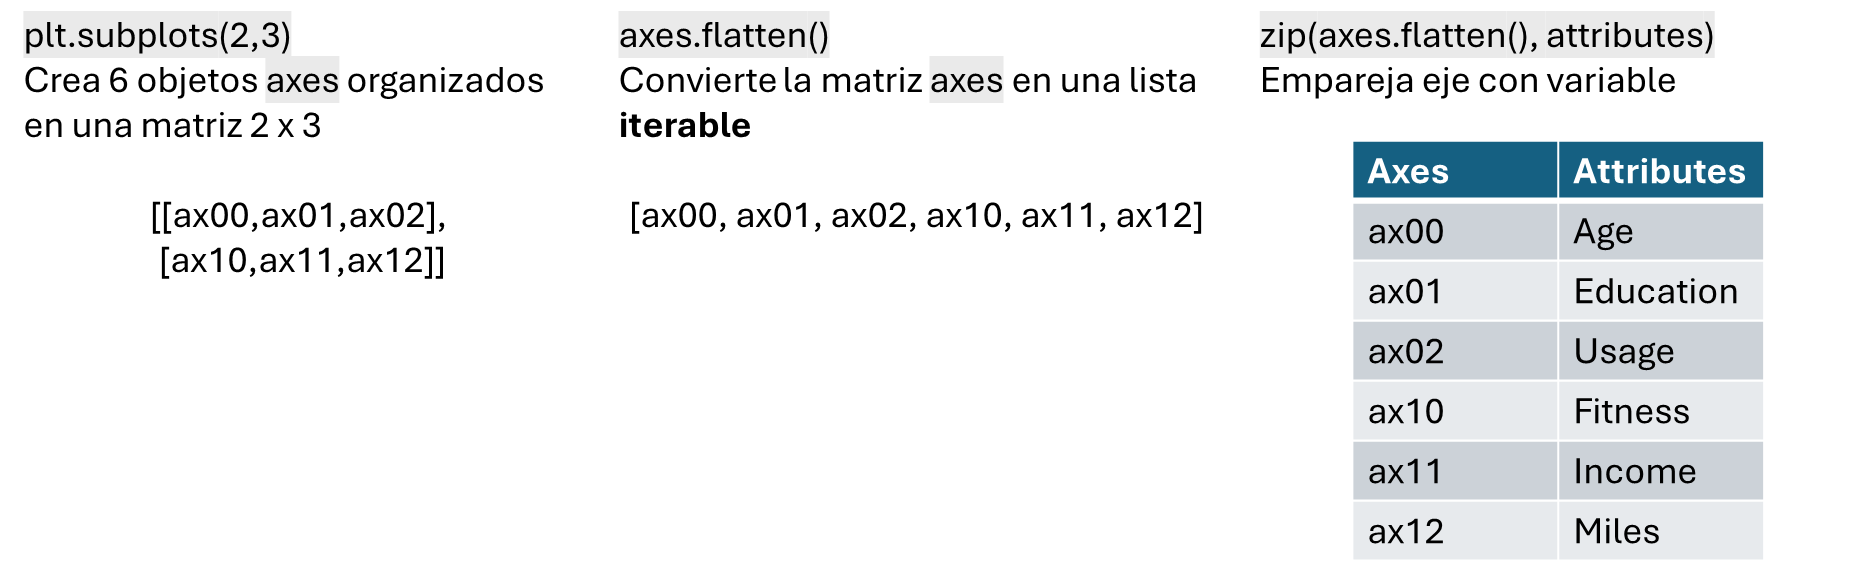

- KP781 destaca en gente con más años de educación, previsión de uso, autovaloración física, salario anual y previsión de millas semanales.
- Los modelos KP281 y KP481 comparten compradores de la misma edad, educación y autovaloración física.

### Análisis multivariable

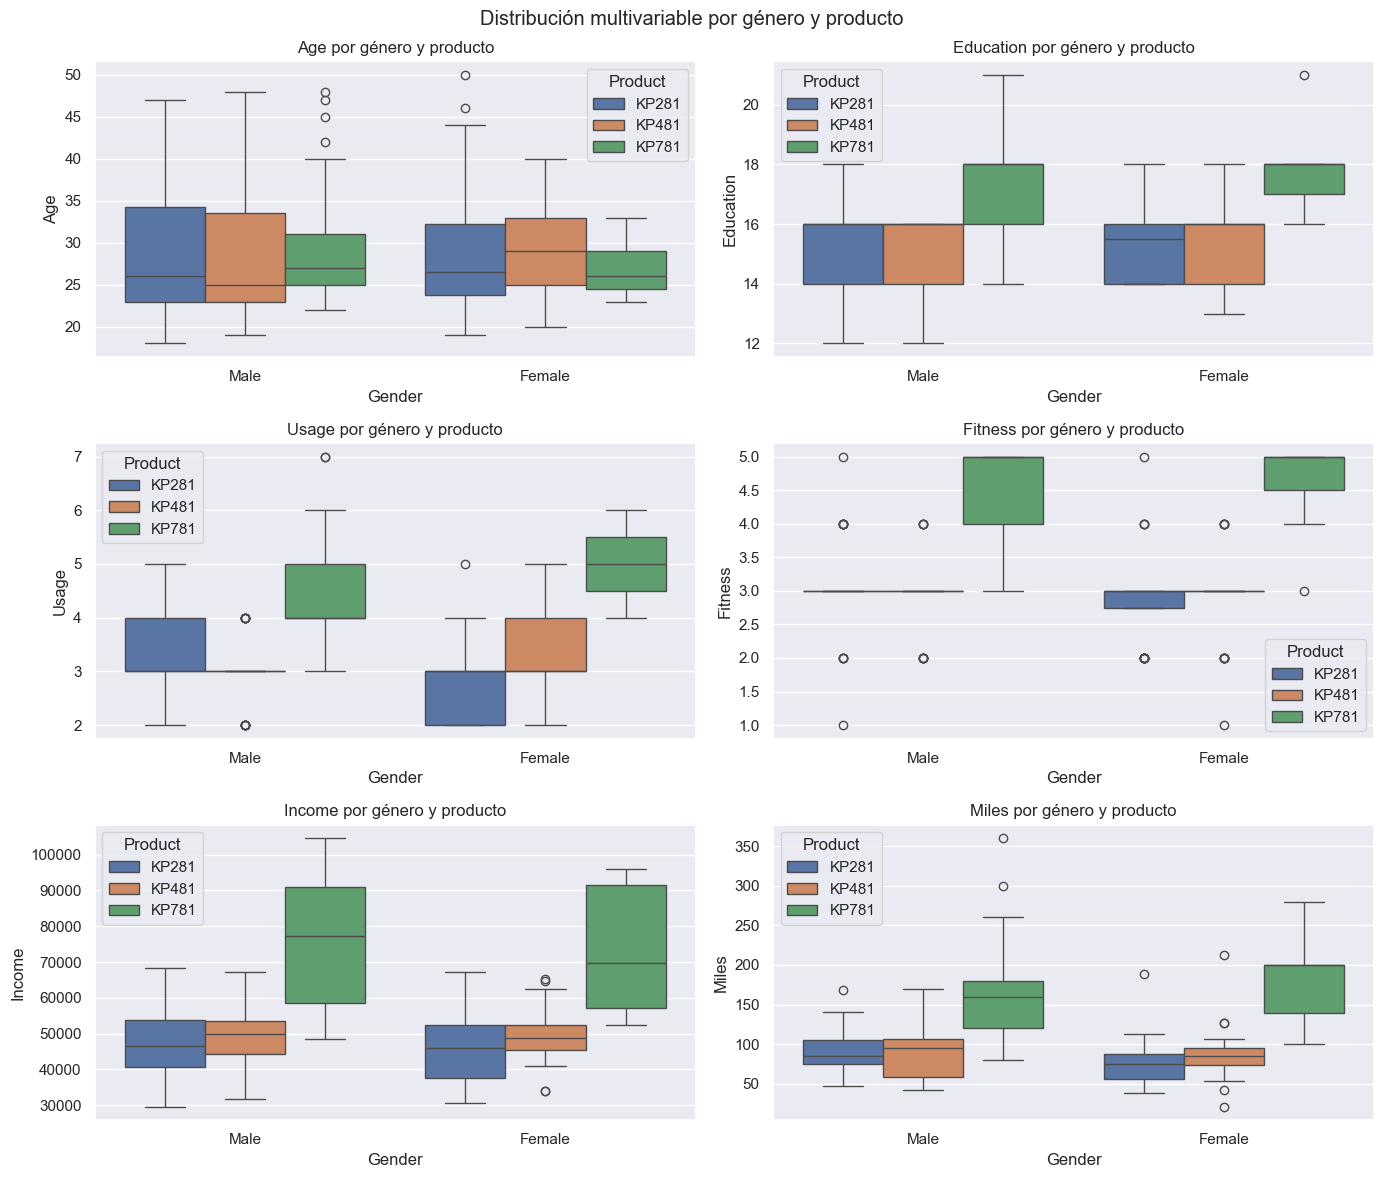

In [40]:
gen_prod_fig, gen_prod_axes = plt.subplots(3, 2, figsize=(14,12))
gen_prod_fig.suptitle("Distribución multivariable por género y producto")

for ax, attr in zip(gen_prod_axes.flatten(), attributes):
    sns.boxplot(
        data=aerofit_df,
        x='Gender',
        y=attr,
        hue='Product',
        ax=ax
    )
    ax.set_title(f"{attr} por género y producto")

plt.tight_layout()
plt.show()

La unica diferencia clara en una variable entre género y producto es en la de días previstos de uso, en la que si una mujer preveé utilizar 3-4 veces a la semana comprará la KP481 y sin embargo si es un hombre la KP281.

### Análisis de Correlación

- Covarianza: Mide como varían dos variables juntas. 
    - Si una sube y la otra tambien -> Positiva
    - Si una sube y la otra no     -> Negativa
    - Si no hay relación -> Cerca de 0
 - Correlación: Mide la covarianza pero normalizada. Sí es interpretable estadísticamente. 3 Métodos disponibles:
    - Pearson: Mide relación lineal. Distribución normal. Sensible a outliers.
    - Spearman: Mide relación monótona. Trabaja con rangos. Más robusta a datos sesgados, outliers, relaciones no lineales y variables ordinales.
    - Kendall: Parecida a Spearman pero mejor en muestras más pequeñas.

Para saber que método es mejor para analizar nuestra correlación se hace siempre primero un scatterplot, un diagrama de puntos. Cada pareja de variables tendrá una correlación que se ajuste más a uno o a otro.

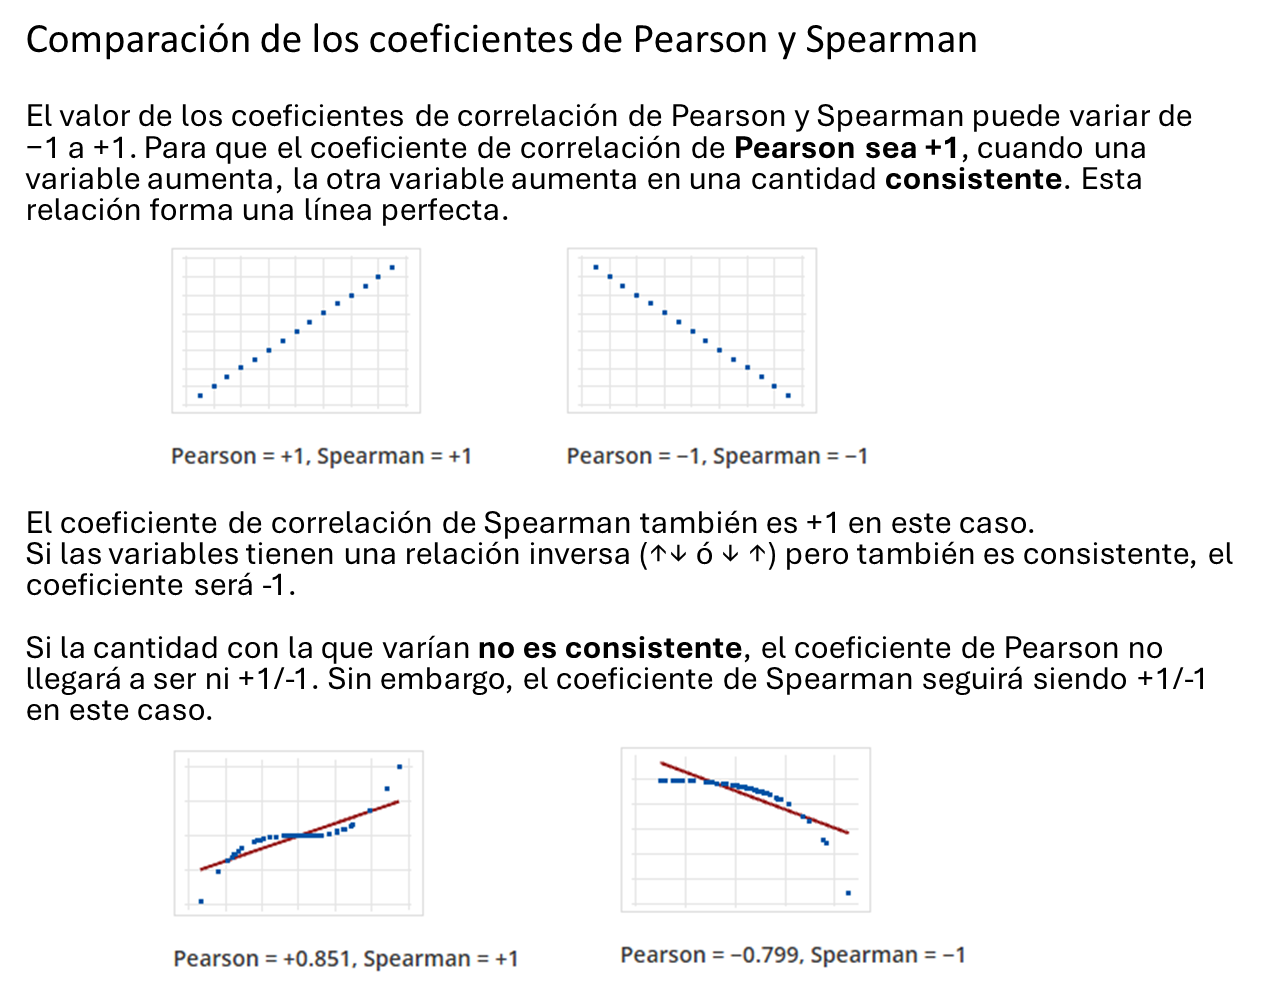


Como la correlación devuelve una matriz cuadrada simétrica, se suele interpretar con heatmap para ver rapidamente que variables tienen correlación.

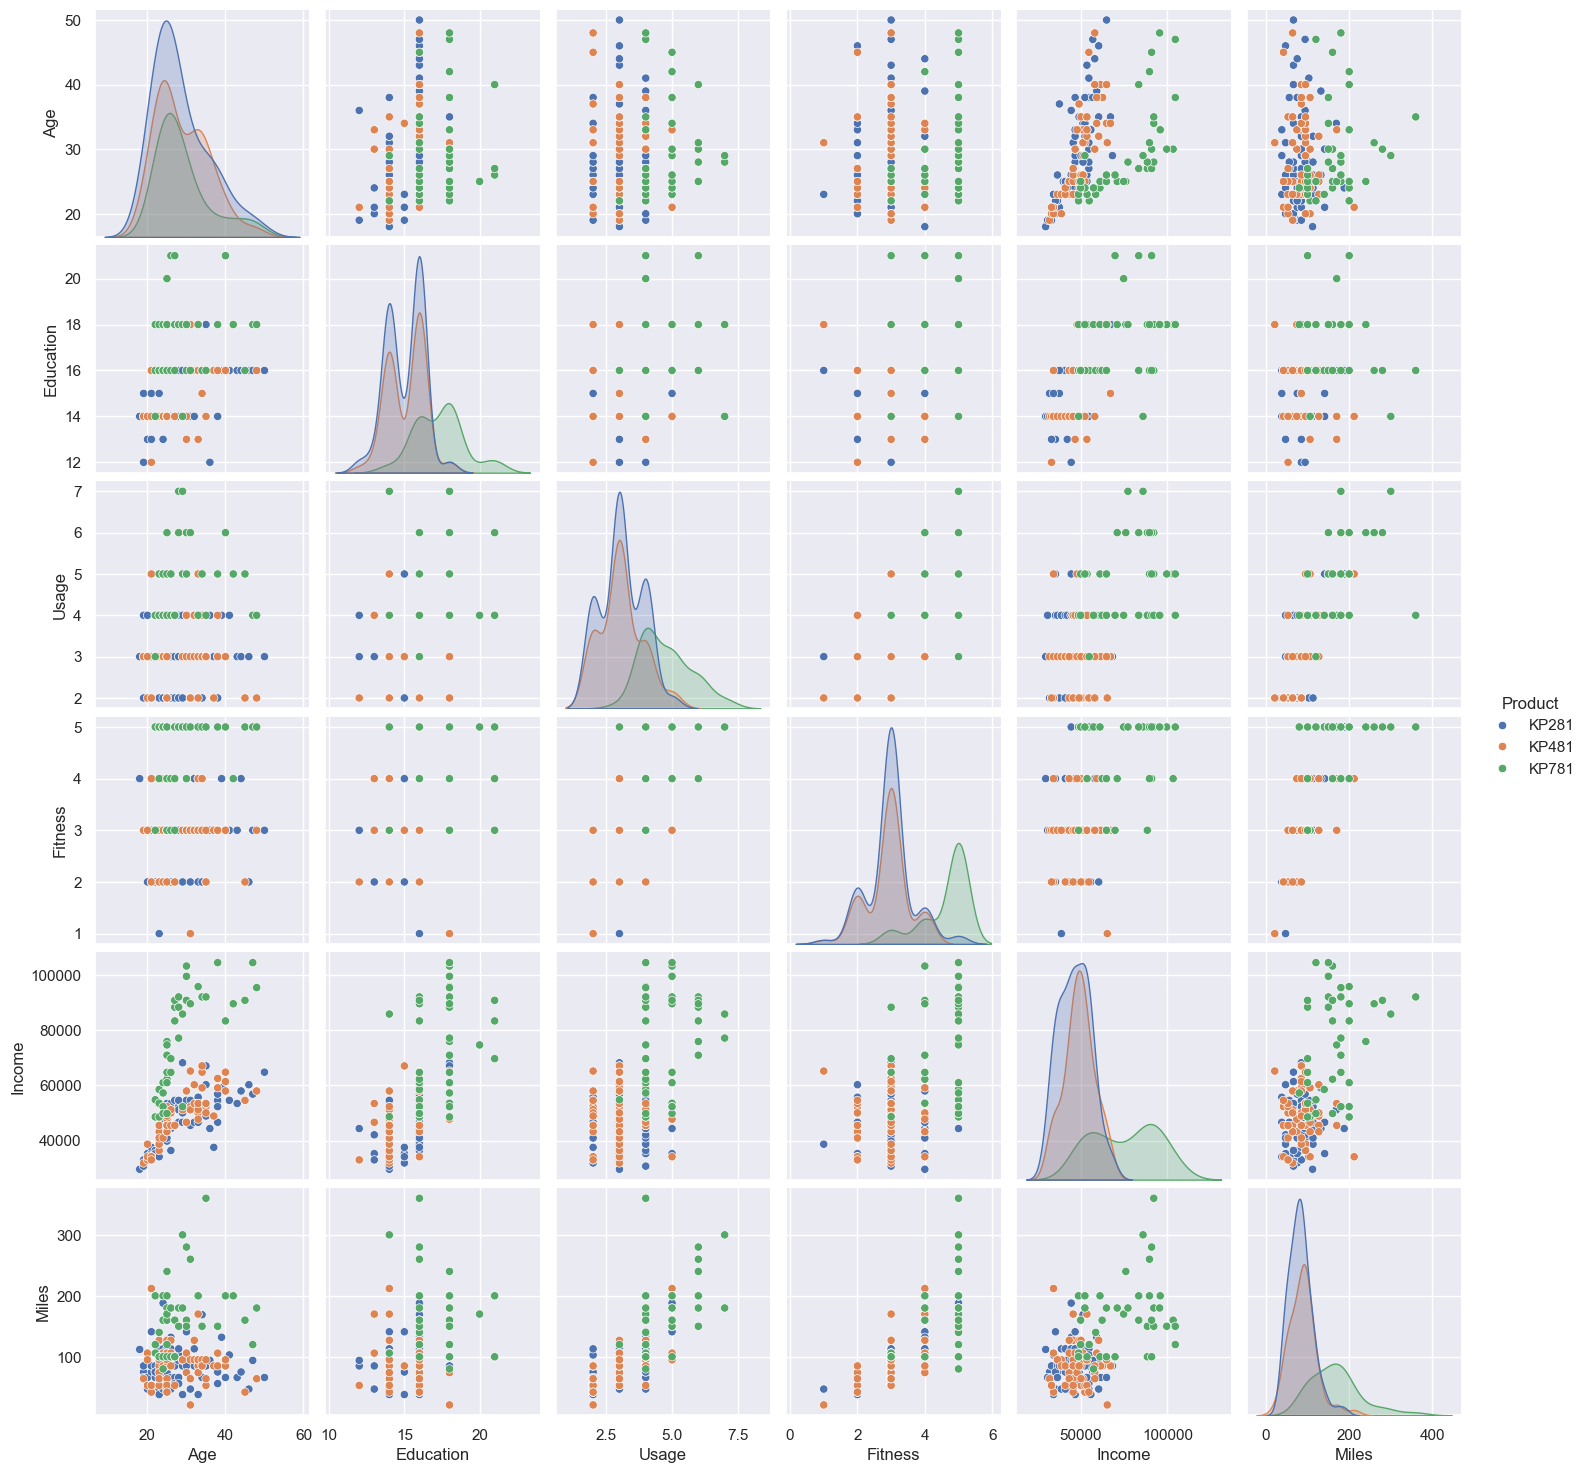

In [55]:
sns.pairplot(
    aerofit_df,
    hue='Product'
)
plt.show()

In [54]:
aerofit_df.corr(method="spearman", numeric_only=True)

,Age,Education,Usage,Fitness,Income,Miles
Age,1.000000,0.332769,0.031330,0.063275,0.683120,0.025457
Education,0.332769,1.000000,0.380321,0.390246,0.616526,0.300469
Usage,0.031330,0.380321,1.000000,0.643817,0.372912,0.758502
Fitness,0.063275,0.390246,0.643817,1.000000,0.396511,0.816037
Income,0.683120,0.616526,0.372912,0.396511,1.000000,0.356775
Miles,0.025457,0.300469,0.758502,0.816037,0.356775,1.000000


In [41]:
num_df = aerofit_df.select_dtypes(include='number')

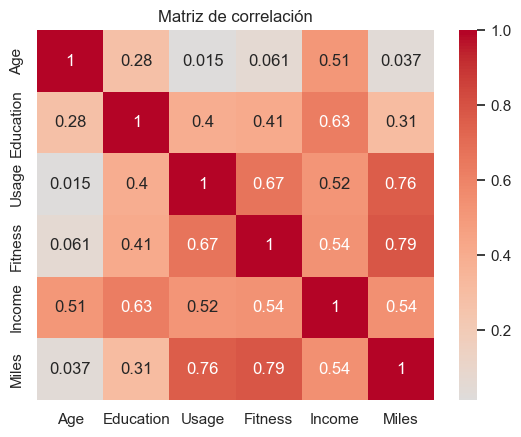

In [56]:
corr = num_df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    center=0
)
plt.title("Matriz de correlación")
plt.show()
